# DANDI Dataset to Experanto

This notebook converts [DANDI Archive](https://dandiarchive.org) datasets into [Experanto](https://github.com/sensorium-competition/experanto) format across multiple neural data modalities.

| Dataset | Modalities | Interpolators |
|---|---|---|
| DANDI:000128 MC_Maze | Spike trains | `SpikeInterpolator` |
| DANDI:000039 Allen Visual Coding | Calcium imaging | `SequenceInterpolator` |
| DANDI:000623 Human MTL (Chandravadia et al.) | Spikes + LFP macro/micro + eye tracking + pupil | `SpikeInterpolator` + `SequenceInterpolator` |


The right interpolator depends on how the data is sampled:
- **Irregular discrete events** (spike trains) → `SpikeInterpolator`
- **Regular continuous signals** (LFP, EEG, calcium, running speed) → `SequenceInterpolator`
- **Labeled time intervals** (trial splits, behavioral states) → `TimeIntervalInterpolator`

For multimodal datasets, each modality gets its own subfolder. A folder is only created if that modality actually exists in the file.

In [4]:
!pip install -q git+https://github.com/sensorium-competition/experanto.git@main
!pip install -q dandi pynwb matplotlib PyYAML hydra-core
!pip install -q "numba>=0.61.0" --upgrade

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 54.5 MB/s eta 0:00:

# Note: a one-time runtime restart is required after running above cell.
Colab ships with numba 0.60.0 which doesn't support numpy 2.x. SpikeInterpolator uses numba internally, so this conflict occurs.


In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO
from experanto.interpolators import SpikeInterpolator, SequenceInterpolator

In [2]:
def download_smallest(dandiset_id, dest):
    """
    Downloads the smallest file in a dandiset for testing purposes.
    In practice, you would select a specific asset by path or asset ID
    rather than sorting by size.
    """
    os.makedirs(dest, exist_ok=True)
    client = DandiAPIClient()
    assets = sorted(
        client.get_dandiset(dandiset_id).get_assets(),
        key=lambda x: x.size
    )
    path = f"{dest}/test.nwb"
    if not os.path.exists(path):
        print(f"Downloading {assets[0].path} ({round(assets[0].size/1e6, 1)} MB)")
        assets[0].download(path)
    else:
        print(f"Using cached: {path}")
    return path

In [3]:
def inspect_nwb(nwb):
    """Print a summary of what modalities are present in an NWB file."""
    print("Acquisition:")
    for name, obj in nwb.acquisition.items():
        print(f"  {name}: {type(obj).__name__}")
    print("Processing modules:")
    for mod_name, module in nwb.processing.items():
        for dname, dobj in module.data_interfaces.items():
            print(f"  {mod_name}/{dname}: {type(dobj).__name__}")
    print(f"Units:  {len(nwb.units) if nwb.units else 'None'}")
    print(f"Trials: {len(nwb.trials) if nwb.trials else 'None'}")

In [4]:
def detect_modalities(nwb):
    """
    Detect which Experanto modalities are present in an NWB file
    and suggest the appropriate interpolator for each.

    Only modalities that actually contain data are returned
    this ensures only the corresponding folders get created.

    Returns a dict mapping modality name → suggested interpolator.
    Always verify against the dataset documentation before converting.
    """
    modalities = {}

    if nwb.units is not None and "spike_times" in list(nwb.units.colnames):
        modalities["spikes"] = "SpikeInterpolator"

    for name, obj in nwb.acquisition.items():
        t = type(obj).__name__
        if "ElectricalSeries" in t:
            modalities[name.lower()] = "SequenceInterpolator"
        elif "NIRSSeries" in t:
            modalities[name.lower()] = "SequenceInterpolator"
        elif "ImageSeries" in t or "TwoPhotonSeries" in t:
            modalities[name.lower()] = "ScreenInterpolator"

    for mod_name, module in nwb.processing.items():
        for dname, dobj in module.data_interfaces.items():
            t = type(dobj).__name__
            if "LFP" in t:
                for sname in dobj.electrical_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "Fluorescence" in t:
                for sname in dobj.roi_response_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "BehavioralTimeSeries" in t:
                for sname in dobj.time_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "EyeTracking" in t:
                for sname in dobj.spatial_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "PupilTracking" in t:
                for sname in dobj.time_series:
                    modalities[sname.lower()] = "SequenceInterpolator"
            elif "FiberPhotometry" in t:
                modalities[dname.lower()] = "SequenceInterpolator"
            elif "TimeSeries" in t:
                modalities[dname.lower()] = "SequenceInterpolator (verify manually)"

    for name, interp in modalities.items():
        print(f"  {name:5s} : {interp}")
    return modalities


#  Spike trains DANDI:000128 MC_Maze

Macaque motor cortex, 137 neurons, 574 reaching trials

Modality: irregular discrete events [SpikeInterpolator]

In [5]:
path_128 = download_smallest("000128", "data/000128")
io128 = NWBHDF5IO(path_128, "r")
nwb128 = io128.read()
inspect_nwb(nwb128)

Using cached: data/000128/test.nwb
Acquisition:
Processing modules:
Units:  137
Trials: 574


In [6]:
result_128 = detect_modalities(nwb128)

  spikes : SpikeInterpolator


In [7]:
def convert_spikes(nwb, output_dir):
    """
    Convert NWB spike times to SpikeInterpolator format.

    NWB stores one spike_times array per unit. SpikeInterpolator
    expects a single flat 1D array (spikes.npy) with all neurons
    concatenated and sorted within each block. spike_indices in
    meta.yml marks the boundary between each neuron's block.
    """
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    units_df = nwb.units.to_dataframe()
    trials_df = nwb.trials.to_dataframe()
    t_start = float(trials_df["start_time"].min())
    t_end = float(trials_df["stop_time"].max())
    n_neurons = len(units_df)

    all_spikes, spike_indices = [], [0]
    for _, unit in units_df.iterrows():
        spikes = np.sort(np.array(unit["spike_times"], dtype=np.float64))
        all_spikes.append(spikes)
        spike_indices.append(spike_indices[-1] + len(spikes))

    flat = np.concatenate(all_spikes)
    np.save(out / "spikes.npy", flat)
    yaml.safe_dump({
        "modality": "spikes",
        "start_time": t_start,
        "end_time": t_end,
        "n_signals": n_neurons,
        "spike_indices": [int(i) for i in spike_indices],
        "dtype": "float64",
        "is_mem_mapped": False,
    }, open(out / "meta.yml", "w"))

    print(f"Duration:         {t_end - t_start:.1f}s")
    print(f"Neurons:          {n_neurons}")
    print(f"Total spikes:     {len(flat):,}")
    print(f"Mean per neuron:  {len(flat)/n_neurons:.0f}")
    return flat, t_start, t_end

In [8]:
flat_128, t0_128, t1_128 = convert_spikes(nwb128, "experanto_000128/spikes")
io128.close()

Duration:         459.1s
Neurons:          137
Total spikes:     230,348
Mean per neuron:  1681


In [9]:
si128 = SpikeInterpolator(
    "experanto_000128/spikes",
    cache_data=True,
    interpolation_window=0.1,
    interpolation_align="center",
)

t = np.linspace(si128.start_time + 1, si128.start_time + 100, 500)
counts_128 = si128.interpolate(t)
print(f"Output shape: {counts_128.shape}")
print(f"Mean spikes per window: {counts_128.mean():.4f}")

Output shape: (500, 137)
Mean spikes per window: 0.3705


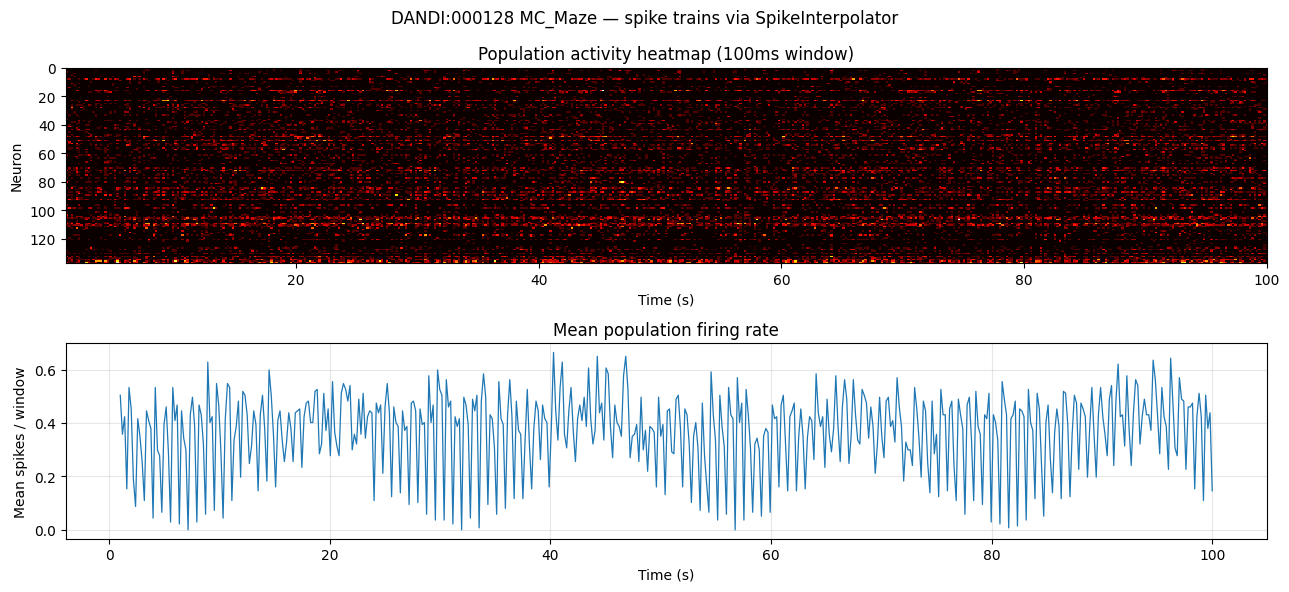

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
fig.suptitle("DANDI:000128 MC_Maze — spike trains via SpikeInterpolator")

axes[0].imshow(
    counts_128.T,
    aspect="auto",
    cmap="hot",
    interpolation="nearest",
    extent=[t[0], t[-1], counts_128.shape[1], 0]
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Neuron")
axes[0].set_title("Population activity heatmap (100ms window)")

axes[1].plot(t, counts_128.mean(axis=1), lw=0.9)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Mean spikes / window")
axes[1].set_title("Mean population firing rate")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcium imaging DANDI:000039 Allen Visual Coding

Mouse visual cortex, dF/F at ~30Hz

Modality: regularly sampled continuous signal [SequenceInterpolator]

In [11]:
path_039 = download_smallest("000039", "data/000039")
io039 = NWBHDF5IO(path_039, "r")
nwb039 = io039.read()
inspect_nwb(nwb039)

Using cached: data/000039/test.nwb
Acquisition:
Processing modules:
  brain_observatory_pipeline/Fluorescence: Fluorescence
  brain_observatory_pipeline/ImageSegmentation: ImageSegmentation
  brain_observatory_pipeline/MotionCorrection: TimeSeries
  brain_observatory_pipeline/RunningBehavior: BehavioralTimeSeries
  brain_observatory_pipeline/l0_events: Fluorescence
  brain_observatory_pipeline/max_project: TwoPhotonSeries
  stimulus/timestamps: TimeSeries
Units:  3
Trials: None


In [12]:
result_039 = detect_modalities(nwb039)

  dfoverf : SequenceInterpolator
  demixed_traces : SequenceInterpolator
  neuropil_traces : SequenceInterpolator
  raw_traces : SequenceInterpolator
  motioncorrection : SequenceInterpolator (verify manually)
  running_speed : SequenceInterpolator
  dff_events : SequenceInterpolator
  true_false_events : SequenceInterpolator
  timestamps : SequenceInterpolator (verify manually)


In [13]:
def convert_sequence(data, timestamps, output_dir):
    """
    Save a regularly sampled signal to SequenceInterpolator format.

    time_delta computed as (end_time - start_time) / (n_samples - 1)
    when a fixed rate is not stored in the NWB file.

    Data is saved as a float32 matrix of shape (n_timestamps, n_signals).
    """
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    if data.ndim == 1:
        data = data.reshape(-1, 1)
    data = data.astype(np.float32)

    time_delta = float((timestamps[-1] - timestamps[0]) / (len(timestamps) - 1))

    np.save(out / "data.npy", data)
    yaml.safe_dump({
        "modality": "sequence",
        "sampling_rate": float(1.0 / time_delta),
        "time_delta": time_delta,
        "start_time": float(timestamps[0]),
        "end_time": float(timestamps[-1]),
        "n_signals": int(data.shape[1]),
        "n_timestamps": int(data.shape[0]),
        "dtype": "float32",
        "is_mem_mapped": False,
        "phase_shift_per_signal": False,
    }, open(out / "meta.yml", "w"))

    print(f"Shape:      {data.shape}")
    print(f"Rate:       {1/time_delta:.2f} Hz")
    print(f"Duration:   {timestamps[-1] - timestamps[0]:.1f}s")
    return data, timestamps

In [14]:
fluoro = nwb039.processing["brain_observatory_pipeline"]["Fluorescence"]
trace = fluoro.roi_response_series["DfOverF"]
ca_timestamps = trace.timestamps[:]
ca_data = trace.data[:]

deltas = np.diff(ca_timestamps)
print(f"Stored rate:  {trace.rate}  <- None means timestamps array is used")
print(f"Delta std:    {deltas.std():.2e}  <- ~zero, treating as regularly sampled")
print(f"Inferred rate: {1/deltas.mean():.2f} Hz")

ca_data, ca_ts = convert_sequence(ca_data, ca_timestamps, "experanto_000039/calcium")
io039.close()

Stored rate:  None  <- None means timestamps array is used
Delta std:    5.00e-06  <- ~zero, treating as regularly sampled
Inferred rate: 30.14 Hz
Shape:      (107115, 3)
Rate:       30.14 Hz
Duration:   3553.5s


In [15]:
seq039 = SequenceInterpolator("experanto_000039/calcium")

t_ca = np.linspace(seq039.start_time + 1, seq039.start_time + 100, 500)
ca_result = seq039.interpolate(t_ca)
print(f"Output shape: {ca_result.shape}")
print(f"Mean dF/F:    {ca_result.mean():.4f}")

Output shape: (500, 3)
Mean dF/F:    0.0625


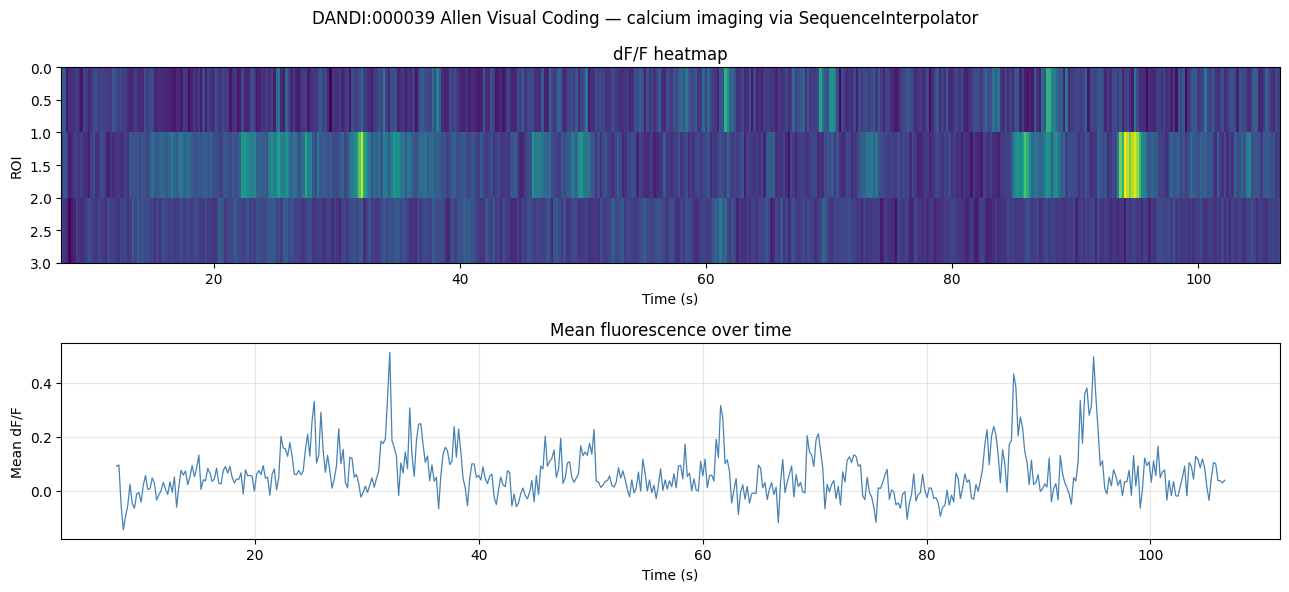

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
fig.suptitle("DANDI:000039 Allen Visual Coding — calcium imaging via SequenceInterpolator")

axes[0].imshow(
    ca_result.T,
    aspect="auto",
    cmap="viridis",
    interpolation="nearest",
    extent=[t_ca[0], t_ca[-1], ca_result.shape[1], 0]
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("ROI")
axes[0].set_title("dF/F heatmap")

axes[1].plot(t_ca, ca_result.mean(axis=1), lw=0.9, color="steelblue")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Mean dF/F")
axes[1].set_title("Mean fluorescence over time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Multiple modalities — DANDI:000623 (Chandravadia et al.)
Human single-neuron recordings during movie watching

Modalities present: spikes, LFP macro, LFP micro, eye tracking, pupil size

`detect_modalities()` is called first to confirm which folders to create. Only existing modalities get a folder.

In [17]:
path_623 = download_smallest("000623", "data/000623")
io623 = NWBHDF5IO(path_623, "r")
nwb623 = io623.read()
inspect_nwb(nwb623)


Using cached: data/000623/test.nwb
Acquisition:
  events_ttl: TimeSeries
  experiment_ids: TimeSeries
Processing modules:
  behavior/Blink: BehavioralTimeSeries
  behavior/EyeTracking: EyeTracking
  behavior/Fixation: BehavioralTimeSeries
  behavior/PupilTracking: PupilTracking
  behavior/Saccade: BehavioralTimeSeries
  ecephys/LFP_macro: LFP
  ecephys/LFP_micro: LFP
Units:  44
Trials: 41


In [18]:
result_623 = detect_modalities(nwb623)

  spikes : SpikeInterpolator
  timeseries : SequenceInterpolator
  spatialseries : SequenceInterpolator
  electricalseries : SequenceInterpolator


In [19]:
base = "experanto_000623"
converted = {}

print("Converting spikes")
flat_623, t0_623, t1_623 = convert_spikes(nwb623, f"{base}/spikes")
converted["spikes"] = f"{base}/spikes"


Converting spikes
Duration:         721.3s
Neurons:          44
Total spikes:     76,279
Mean per neuron:  1734


In [20]:
print("\nConverting LFP macro")
lfp_macro = nwb623.processing["ecephys"]["LFP_macro"]
series = list(lfp_macro.electrical_series.values())[0]
data = series.data[:]
timestamps = np.arange(data.shape[0]) / series.rate
convert_sequence(data, timestamps, f"{base}/lfp_macro")
converted["lfp_macro"] = f"{base}/lfp_macro"


Converting LFP macro
Shape:      (732519, 40)
Rate:       1000.00 Hz
Duration:   732.5s


In [21]:
print("\nConverting LFP micro")
lfp_micro = nwb623.processing["ecephys"]["LFP_micro"]
series = list(lfp_micro.electrical_series.values())[0]
data = series.data[:]
timestamps = np.arange(data.shape[0]) / series.rate
convert_sequence(data, timestamps, f"{base}/lfp_micro")
converted["lfp_micro"] = f"{base}/lfp_micro"


Converting LFP micro
Shape:      (732343, 56)
Rate:       1000.00 Hz
Duration:   732.3s


In [22]:
print("\nConverting eye tracking")
eye = nwb623.processing["behavior"]["EyeTracking"]
series = list(eye.spatial_series.values())[0]
data = series.data[:]
timestamps = np.arange(data.shape[0]) / series.rate
convert_sequence(data, timestamps, f"{base}/eye_tracking")
converted["eye_tracking"] = f"{base}/eye_tracking"


Converting eye tracking
Shape:      (361151, 2)
Rate:       500.00 Hz
Duration:   722.3s


In [23]:
print("\nConverting pupil size")
pupil = nwb623.processing["behavior"]["PupilTracking"]
series = list(pupil.time_series.values())[0]
data = series.data[:]
timestamps = np.arange(data.shape[0]) / series.rate
convert_sequence(data, timestamps, f"{base}/pupil")
converted["pupil"] = f"{base}/pupil"




Converting pupil size
Shape:      (361151, 1)
Rate:       500.00 Hz
Duration:   722.3s


In [24]:
print(f"\nFolders written: {list(converted.keys())}")


Folders written: ['spikes', 'lfp_macro', 'lfp_micro', 'eye_tracking', 'pupil']


In [25]:
si623 = SpikeInterpolator(f"{base}/spikes", cache_data=True, interpolation_window=0.1, interpolation_align="center")
seq_lfp_macro = SequenceInterpolator(f"{base}/lfp_macro")
seq_lfp_micro = SequenceInterpolator(f"{base}/lfp_micro")
seq_eye = SequenceInterpolator(f"{base}/eye_tracking")
seq_pupil = SequenceInterpolator(f"{base}/pupil")

t_start = max(si623.start_time, seq_lfp_macro.start_time, seq_eye.start_time) + 1
t_end = t_start + 60
t_623 = np.linspace(t_start, t_end, 500)

spikes_623 = si623.interpolate(t_623)
lfp_macro_623 = seq_lfp_macro.interpolate(t_623)
lfp_micro_623 = seq_lfp_micro.interpolate(t_623)
eye_623 = seq_eye.interpolate(t_623)
pupil_623 = seq_pupil.interpolate(t_623)

for name, result in [("spikes", spikes_623), ("lfp_macro", lfp_macro_623),
                      ("lfp_micro", lfp_micro_623), ("eye", eye_623), ("pupil", pupil_623)]:
    print(f"  {name}: shape={result.shape}  OK")

  spikes: shape=(500, 44)  OK
  lfp_macro: shape=(500, 40)  OK
  lfp_micro: shape=(500, 56)  OK
  eye: shape=(500, 2)  OK
  pupil: shape=(500, 1)  OK


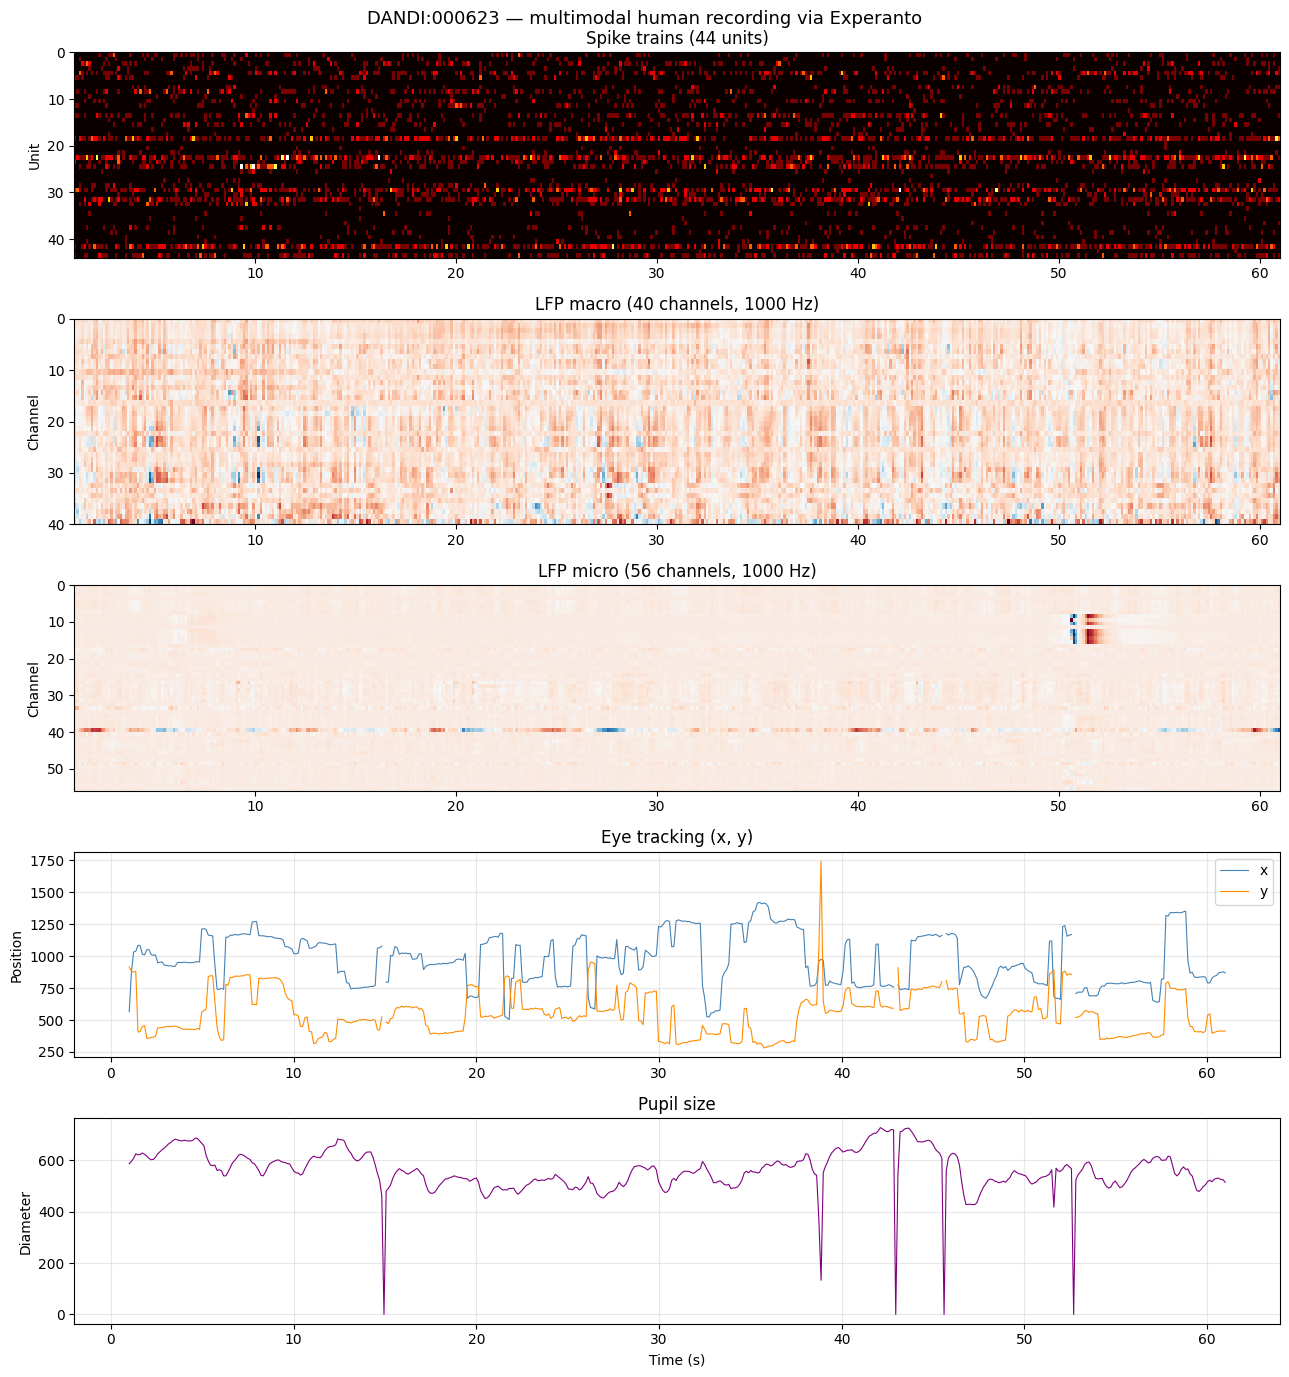

In [26]:
fig, axes = plt.subplots(5, 1, figsize=(13, 14))
fig.suptitle("DANDI:000623 — multimodal human recording via Experanto", fontsize=13)

# Spikes
axes[0].imshow(spikes_623.T, aspect="auto", cmap="hot", interpolation="nearest",
               extent=[t_623[0], t_623[-1], spikes_623.shape[1], 0])
axes[0].set_title("Spike trains (44 units)")
axes[0].set_ylabel("Unit")

# LFP macro
axes[1].imshow(lfp_macro_623.T, aspect="auto", cmap="RdBu_r", interpolation="nearest",
               extent=[t_623[0], t_623[-1], lfp_macro_623.shape[1], 0])
axes[1].set_title("LFP macro (40 channels, 1000 Hz)")
axes[1].set_ylabel("Channel")

# LFP micro
axes[2].imshow(lfp_micro_623.T, aspect="auto", cmap="RdBu_r", interpolation="nearest",
               extent=[t_623[0], t_623[-1], lfp_micro_623.shape[1], 0])
axes[2].set_title("LFP micro (56 channels, 1000 Hz)")
axes[2].set_ylabel("Channel")

# Eye tracking
axes[3].plot(t_623, eye_623[:, 0], lw=0.8, label="x", color="steelblue")
axes[3].plot(t_623, eye_623[:, 1], lw=0.8, label="y", color="darkorange")
axes[3].set_title("Eye tracking (x, y)")
axes[3].set_ylabel("Position")
axes[3].legend(loc="upper right")
axes[3].grid(True, alpha=0.3)

# Pupil
axes[4].plot(t_623, pupil_623[:, 0], lw=0.8, color="purple")
axes[4].set_title("Pupil size")
axes[4].set_xlabel("Time (s)")
axes[4].set_ylabel("Diameter")
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

io623.close()